In [1]:
import numpy as np
import nesspy_analysis as npa
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plot_defaults import *
set_plot_defaults()
whiteout()

Plot defaults set.
Whiteout mode set.


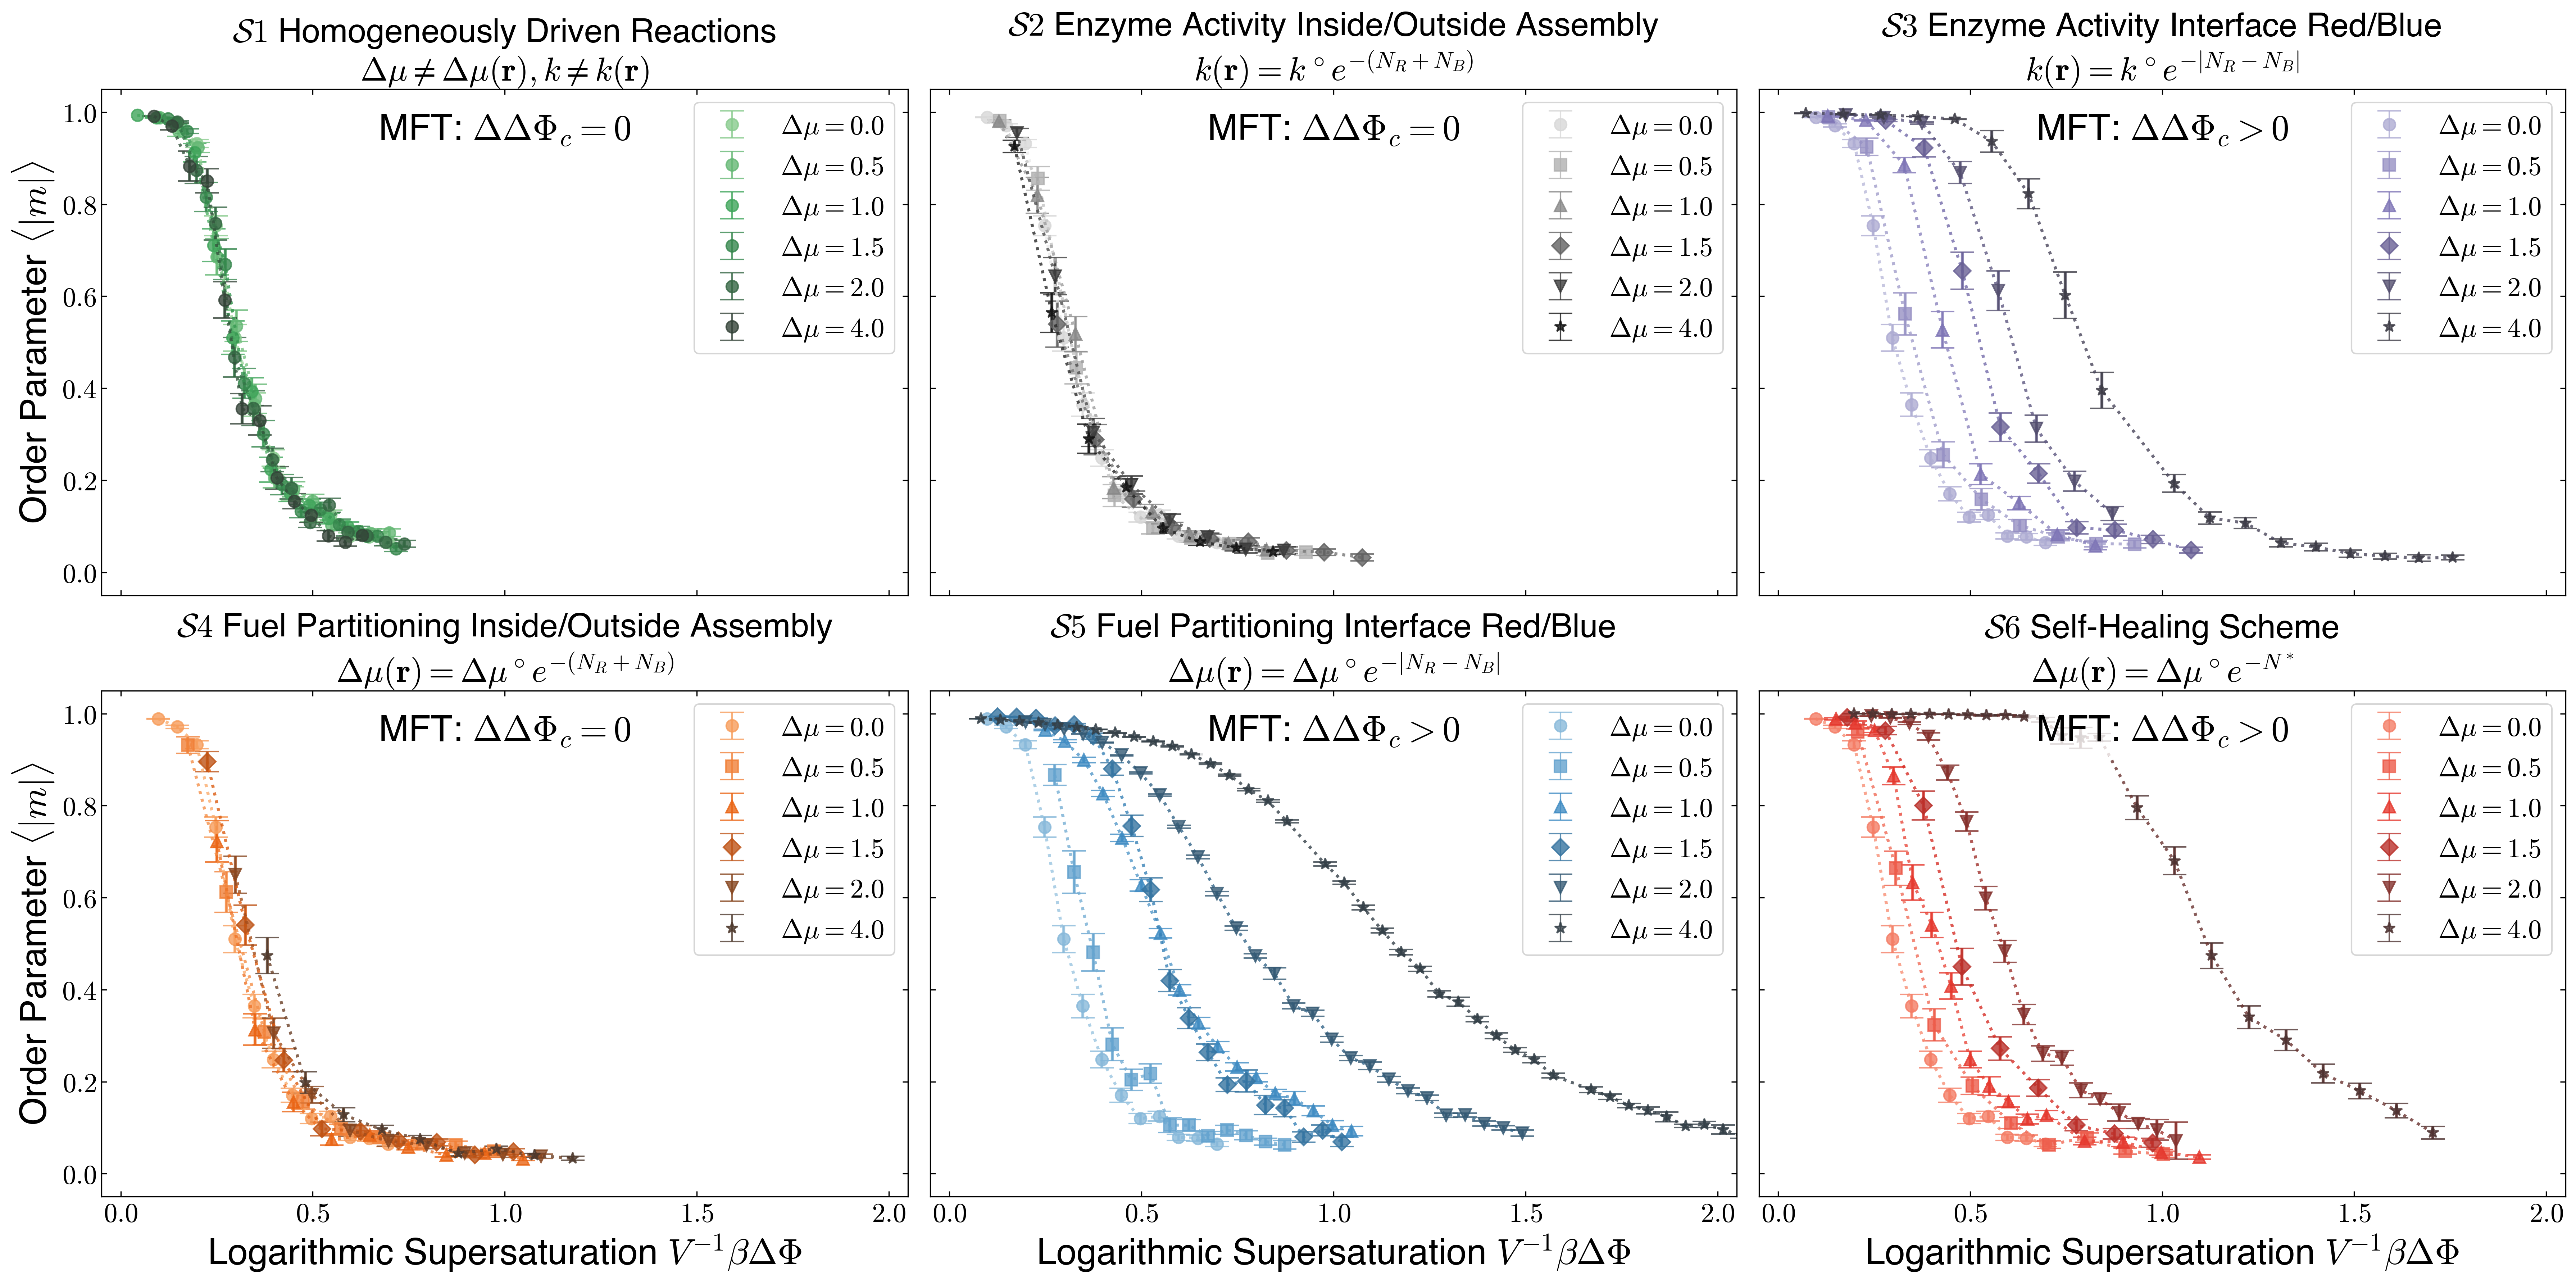

In [2]:
fig, ax = plt.subplots(2,3, figsize=(24,12), sharex=True, sharey=True)

# ax[0,0].set_title(r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    

# ax[1,0].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22) 

# ax[1,1].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)  


# ax[0,2].set_title(r'$k(\mathbf{r}) = k^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)  

# ax[0,1].set_title(r'$k(\mathbf{r}) = k^\circ e^{-(N_R + N_B)}$', fontsize=22)  

# ax[1,2].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-N^*}$', fontsize=22)  


FS_LEGEND = 18
FS_TITLE = 22

ax[0,0].set_title(r'$\mathcal{S}1$ ' 'Homogeneously Driven Reactions \n' r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    
ax[1,0].set_title(r'$\mathcal{S}4$ ' 'Fuel Partitioning Inside/Outside Assembly \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22)    
ax[1,1].set_title(r'$\mathcal{S}5$ ' 'Fuel Partitioning Interface Red/Blue \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)    
 
ax[1,2].set_title(r'$\mathcal{S}6$ ' 'Self-Healing Scheme \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-N^*}$', fontsize=22)    
ax[0,1].set_title(r'$\mathcal{S}2$ ' 'Enzyme Activity Inside/Outside Assembly \n'r'$k(\mathbf{r}) = k^\circ e^{-(N_R + N_B)}$', fontsize=22)    
ax[0,2].set_title(r'$\mathcal{S}3$ ' 'Enzyme Activity Interface Red/Blue \n'r'$k(\mathbf{r}) = k^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)    


PALETTE = 'Paired'
ALPHA=0.8

s6 = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME6_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=12)
colors = sns.color_palette(palette='Blues_d', n_colors=12)

markers = ['o', 's', '^', 'D', 'v', '*']

colors[-2] = colors[-1]
for dmu in s6['dmu'].unique():
    data = s6[s6['dmu'] == dmu]


    ax[1,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s6['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[1,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s6['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s6['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
    
    
ax[1,1].legend(fontsize=FS_LEGEND)


colors = sns.color_palette(palette='Reds_d', n_colors=12)

s7 = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME7_data_df0.0_k1.0.csv")
for dmu in s7['dmu'].unique():
    data = s7[s7['dmu'] == dmu]
    ax[1,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s7['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[1,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s7['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s7['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
    
ax[1,2].legend(fontsize=FS_LEGEND)



s93 = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME93_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette='Purples_d', n_colors=12)

for dmu in s93['dmu'].unique():
    data = s93[s93['dmu'] == dmu]
    ax[0,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s93['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[0,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s93['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s93['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[0,2].legend(fontsize=FS_LEGEND)


colors = sns.color_palette(palette='Greens_d', n_colors=12)

homo = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/HOMO_data_df0.0_k1.0.csv")
homo = homo[homo['dmu'] < 4.5]
for dmu in homo['dmu'].unique():
    data = homo[homo['dmu'] == dmu]
    ax[0,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(homo['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[0,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(homo['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker='o', label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[0,0].legend(fontsize=FS_LEGEND)


s3data = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME3_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette='Oranges_d', n_colors=12)

for dmu in s3data['dmu'].unique():
    data = s3data[s3data['dmu'] == dmu]
    ax[1,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s3data['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[1,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s3data['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s3data['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[1,0].legend(fontsize=FS_LEGEND)


s91_data = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME91_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette='grey_r', n_colors=12)

for dmu in s91_data['dmu'].unique():
    data = s91_data[s91_data['dmu'] == dmu]
    ax[0,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s91_data['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[0,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s91_data['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s91_data['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[0,1].legend(fontsize=FS_LEGEND)

for axis in ax.flat:
    axis.set_xlim(-0.05,2.05)
    axis.set_ylim(-0.05, 1.05)
    axis.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0], [r"$0.0$", "$0.5$", "$1.0$", "$1.5$", "$2.0$"], fontsize=FS_LEGEND)
    axis.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], [r"$0.0$", "$0.2$", "$0.4$", "$0.6$", "$0.8$", "$1.0$"], fontsize=FS_LEGEND)

FS_TITLE = 24
ax[1,0].set_xlabel(r"Logarithmic Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,1].set_xlabel(r"Logarithmic Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,2].set_xlabel(r"Logarithmic Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[0,0].set_ylabel(r"Order Parameter $\langle \vert m \vert \rangle$", fontsize=FS_TITLE)
ax[1,0].set_ylabel(r"Order Parameter $\langle \vert m \vert \rangle$", fontsize=FS_TITLE)


ax[0,0].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,0].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[1,0].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[1,0].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[1,1].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,1].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[1,2].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,2].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[0,1].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,1].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[0,2].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[0,2].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

plt.tight_layout()
plt.savefig('table_whiteout.pdf', bbox_inches='tight')

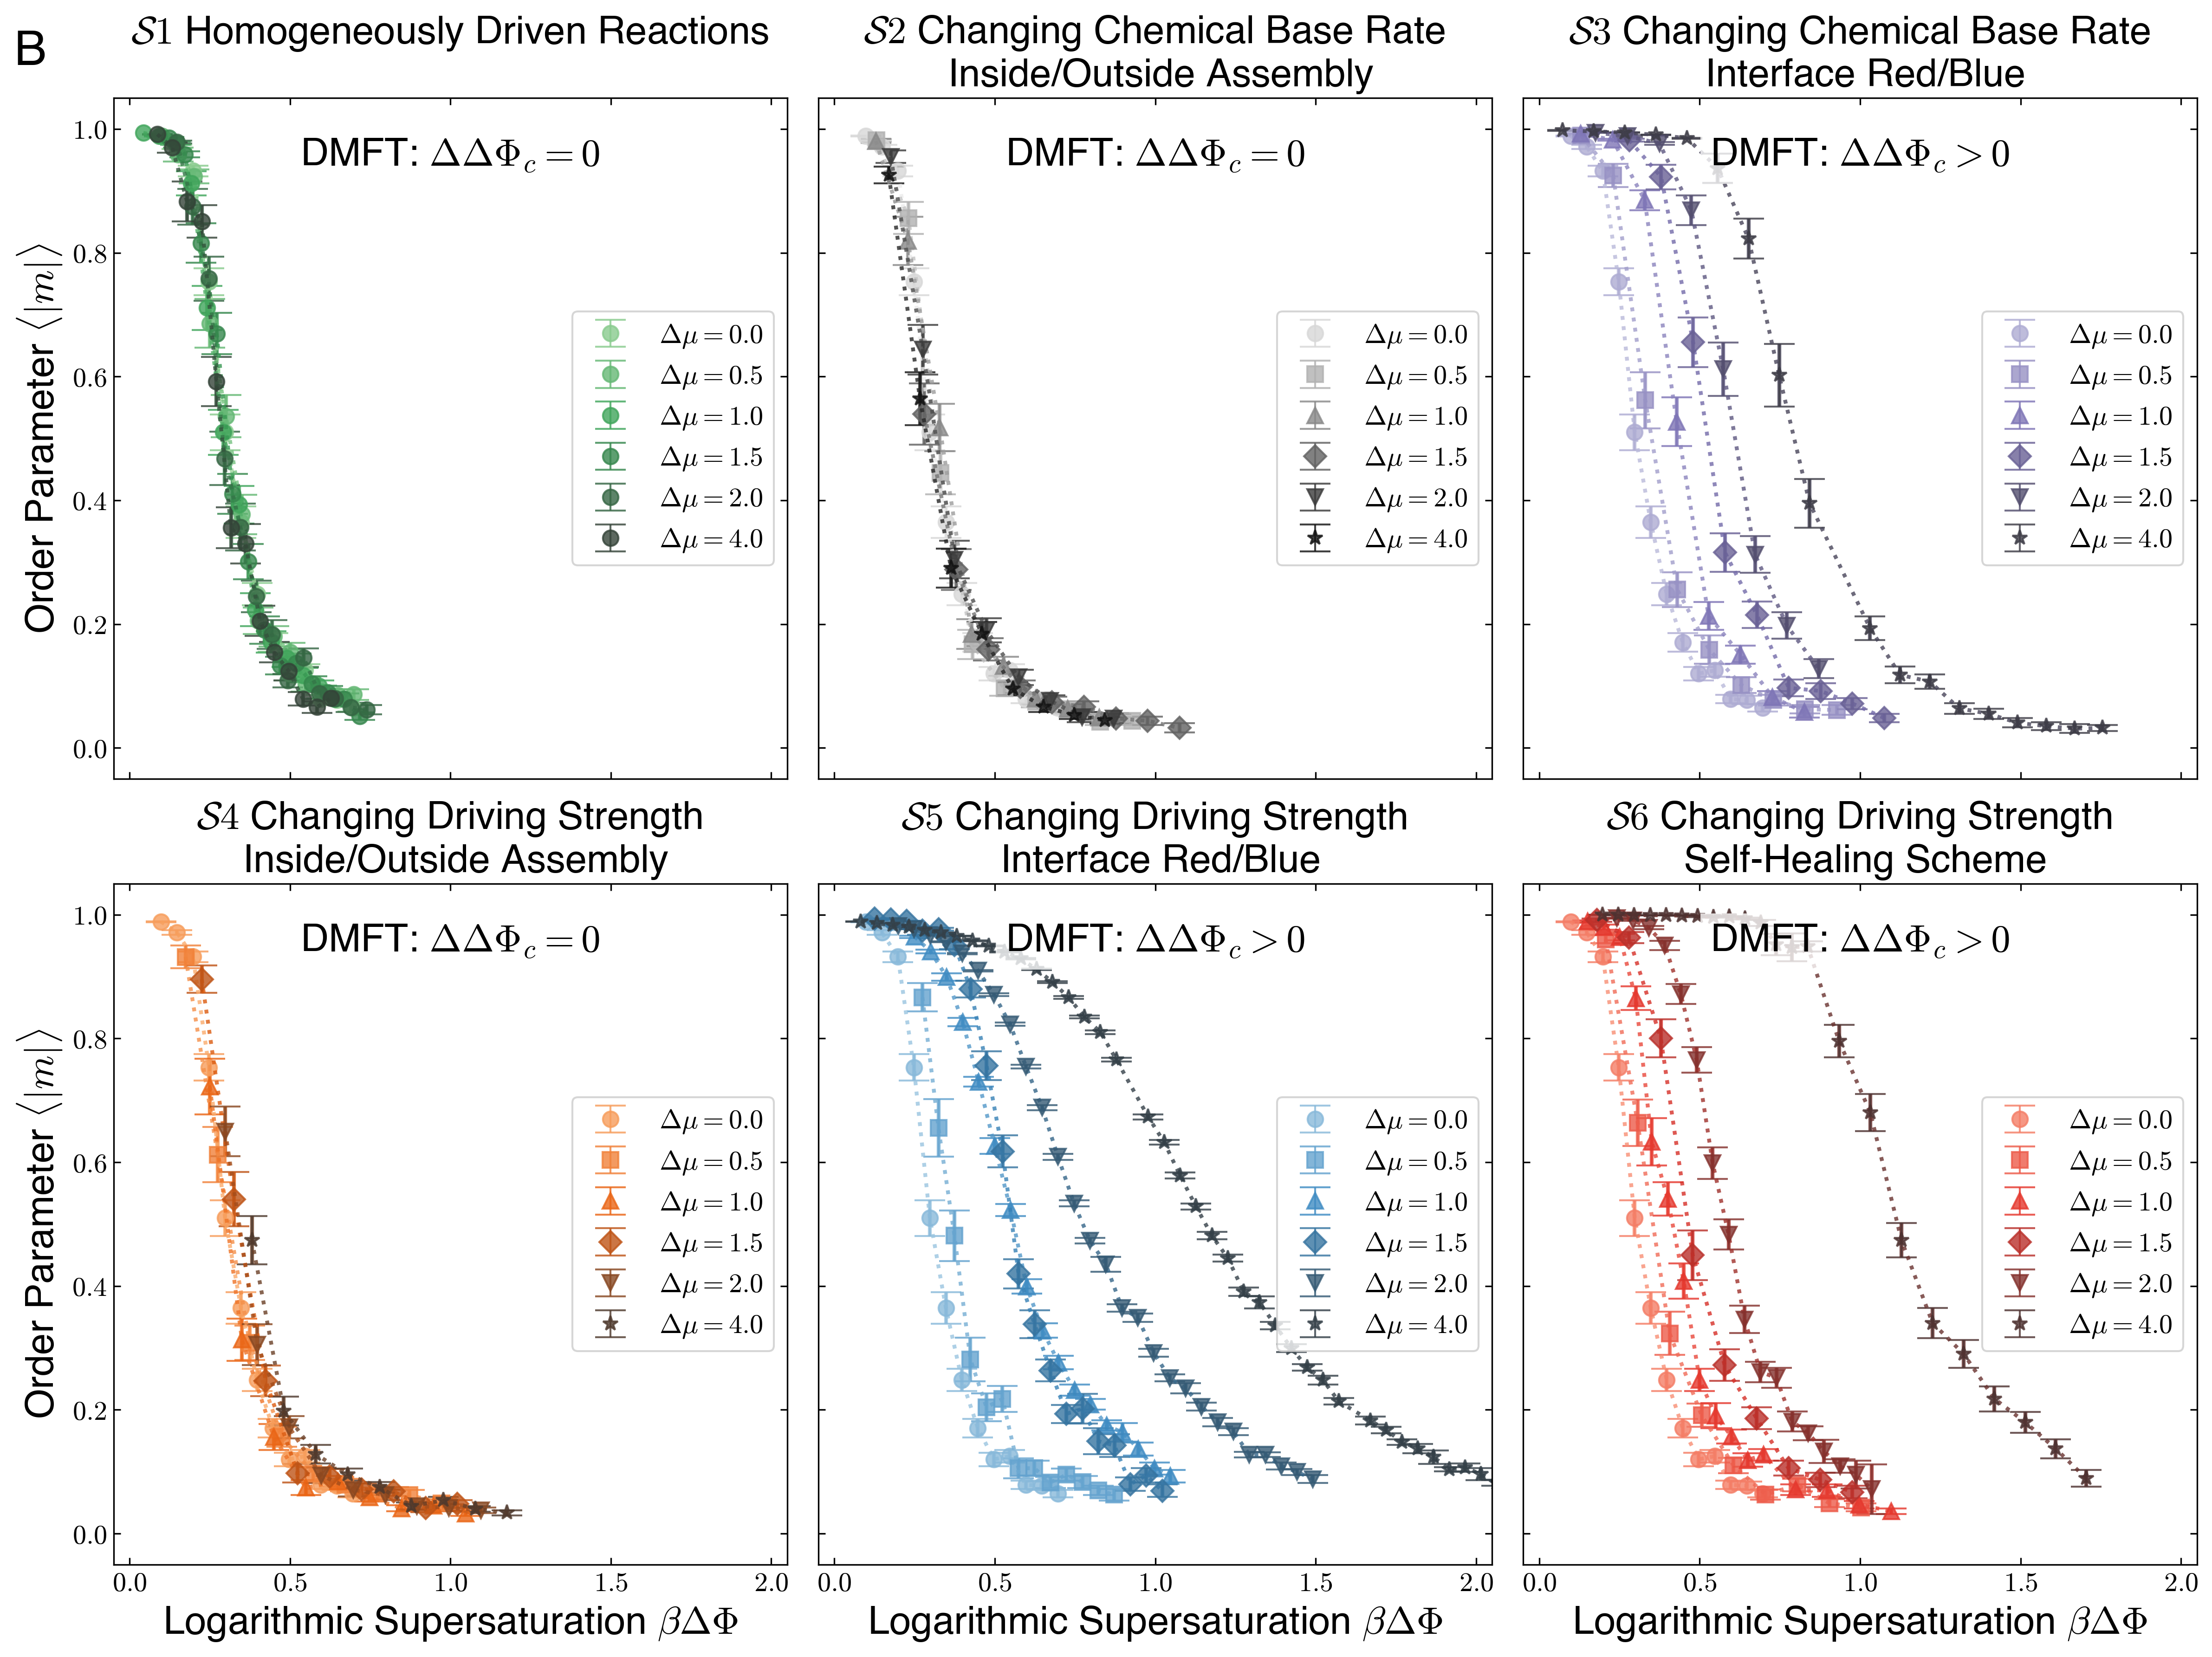

In [50]:
fig, ax = plt.subplots(2,3, figsize=(16,12), sharex=True, sharey=True)

# ax[0,0].set_title(r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    

# ax[1,0].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22) 

# ax[1,1].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)  


# ax[0,2].set_title(r'$k(\mathbf{r}) = k^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)  

# ax[0,1].set_title(r'$k(\mathbf{r}) = k^\circ e^{-(N_R + N_B)}$', fontsize=22)  

# ax[1,2].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-N^*}$', fontsize=22)  


FS_LEGEND = 14
FS_TITLE = 20

# ax[0,0].set_title(r'$\mathcal{S}1$ ' 'Homogeneously Driven Reactions \n' r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    

ax[0,0].set_title(r'$\mathcal{S}1$ ' 'Homogeneously Driven Reactions \n', fontsize=20)    


# ax[1,0].set_title(r'$\mathcal{S}4$ ' 'Fuel Partitioning Inside/Outside Assembly \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22)   
# 
ax[1,0].set_title(r'$\mathcal{S}4$ ' 'Changing Driving Strength \n Inside/Outside Assembly', fontsize=20)    

#  
ax[1,1].set_title(r'$\mathcal{S}5$ ' 'Changing Driving Strength \n Interface Red/Blue', fontsize=20)    
 
ax[1,2].set_title(r'$\mathcal{S}6$ ' 'Changing Driving Strength \n Self-Healing Scheme', fontsize=20)    
ax[0,1].set_title(r'$\mathcal{S}2$ ' 'Changing Chemical Base Rate \n Inside/Outside Assembly', fontsize=20)    
ax[0,2].set_title(r'$\mathcal{S}3$ ' 'Changing Chemical Base Rate \n Interface Red/Blue', fontsize=20)    


PALETTE = 'Paired'
ALPHA=0.8

s6 = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME6_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=12)
colors = sns.color_palette(palette='Blues_d', n_colors=12)

markers = ['o', 's', '^', 'D', 'v', '*']

colors[-2] = colors[-1]
for dmu in s6['dmu'].unique():
    data = s6[s6['dmu'] == dmu]


    ax[1,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s6['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[1,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s6['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s6['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
    
    
ax[1,1].legend(fontsize=FS_LEGEND, loc='center right')


colors = sns.color_palette(palette='Reds_d', n_colors=12)

s7 = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME7_data_df0.0_k1.0.csv")
for dmu in s7['dmu'].unique():
    data = s7[s7['dmu'] == dmu]
    ax[1,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s7['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[1,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s7['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s7['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
    
ax[1,2].legend(fontsize=FS_LEGEND, loc='center right')



s93 = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME93_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette='Purples_d', n_colors=12)

for dmu in s93['dmu'].unique():
    data = s93[s93['dmu'] == dmu]
    ax[0,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s93['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[0,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s93['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s93['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[0,2].legend(fontsize=FS_LEGEND, loc='center right')

colors = sns.color_palette(palette='Greens_d', n_colors=12)

homo = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/HOMO_data_df0.0_k1.0.csv")
homo = homo[homo['dmu'] < 4.5]
for dmu in homo['dmu'].unique():
    data = homo[homo['dmu'] == dmu]
    ax[0,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(homo['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[0,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(homo['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker='o', label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[0,0].legend(fontsize=FS_LEGEND, loc='center right')


s3data = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME3_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette='Oranges_d', n_colors=12)

for dmu in s3data['dmu'].unique():
    data = s3data[s3data['dmu'] == dmu]
    ax[1,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s3data['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[1,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s3data['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s3data['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[1,0].legend(fontsize=FS_LEGEND, loc='center right')


s91_data = pd.read_csv("/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME91_data_df0.0_k1.0.csv")
colors = sns.color_palette(palette='grey_r', n_colors=12)

for dmu in s91_data['dmu'].unique():
    data = s91_data[s91_data['dmu'] == dmu]
    ax[0,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s91_data['dmu'].unique()).index(dmu)],
                     ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)
    ax[0,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[2*list(s91_data['dmu'].unique()).index(dmu)+1],
                     ms=8, ls='none', marker=markers[list(s91_data['dmu'].unique()).index(dmu)], label=fr"$\Delta \mu = {dmu}$", capsize=8, alpha=ALPHA, lw=1)
ax[0,1].legend(fontsize=FS_LEGEND, loc='center right')

for axis in ax.flat:
    axis.set_xlim(-0.05,2.05)
    axis.set_ylim(-0.05, 1.05)
    axis.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0], [r"$0.0$", "$0.5$", "$1.0$", "$1.5$", "$2.0$"], fontsize=FS_LEGEND)
    axis.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], [r"$0.0$", "$0.2$", "$0.4$", "$0.6$", "$0.8$", "$1.0$"], fontsize=FS_LEGEND)

FS_TITLE = 20
ax[1,0].set_xlabel(r"Logarithmic Supersaturation $\beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,1].set_xlabel(r"Logarithmic Supersaturation $\beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,2].set_xlabel(r"Logarithmic Supersaturation $\beta \Delta \Phi$", fontsize=FS_TITLE)
ax[0,0].set_ylabel(r"Order Parameter $\langle \vert m \vert \rangle$", fontsize=FS_TITLE)
ax[1,0].set_ylabel(r"Order Parameter $\langle \vert m \vert \rangle$", fontsize=FS_TITLE)


ax[0,0].text(0.5, 0.9, r'DMFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,0].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[1,0].text(0.5, 0.9, r'DMFT: $\Delta \Delta \Phi_c = 0$', transform=ax[1,0].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[1,1].text(0.5, 0.9, r'DMFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,1].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[1,2].text(0.5, 0.9, r'DMFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,2].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[0,1].text(0.5, 0.9, r'DMFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,1].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

ax[0,2].text(0.5, 0.9, r'DMFT: $\Delta \Delta \Phi_c > 0$', transform=ax[0,2].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=ALPHA, edgecolor='none', pad=5.0))

plt.tight_layout()

ax[0,0].text(
    -0.1,
    1.1,
    "B",
    transform=ax[0,0].transAxes,
    fontsize=25,
    fontweight="bold",
    va="top",
    ha="right",
)

plt.savefig('table_whiteout_two_thirds.pdf', bbox_inches='tight')

/Volumes/2025/2026_paper/COMPARING_SCHEMES/HOMO_data_df0.0_k1.0.csv
0.0
0.5
1.0
1.5
2.0
4.0
/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME91_data_df0.0_k1.0.csv
0.0
0.5
1.0
1.5
2.0
4.0
/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME93_data_df0.0_k1.0.csv
0.0
0.5
1.0
1.5
2.0
4.0
/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME3_data_df0.0_k1.0.csv
0.0
0.5
1.0
1.5
2.0
4.0
/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME6_data_df0.0_k1.0.csv
0.0
0.5
1.0
1.5
2.0
4.0
/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME7_data_df0.0_k1.0.csv
0.0
0.5
1.0
1.5
2.0
4.0


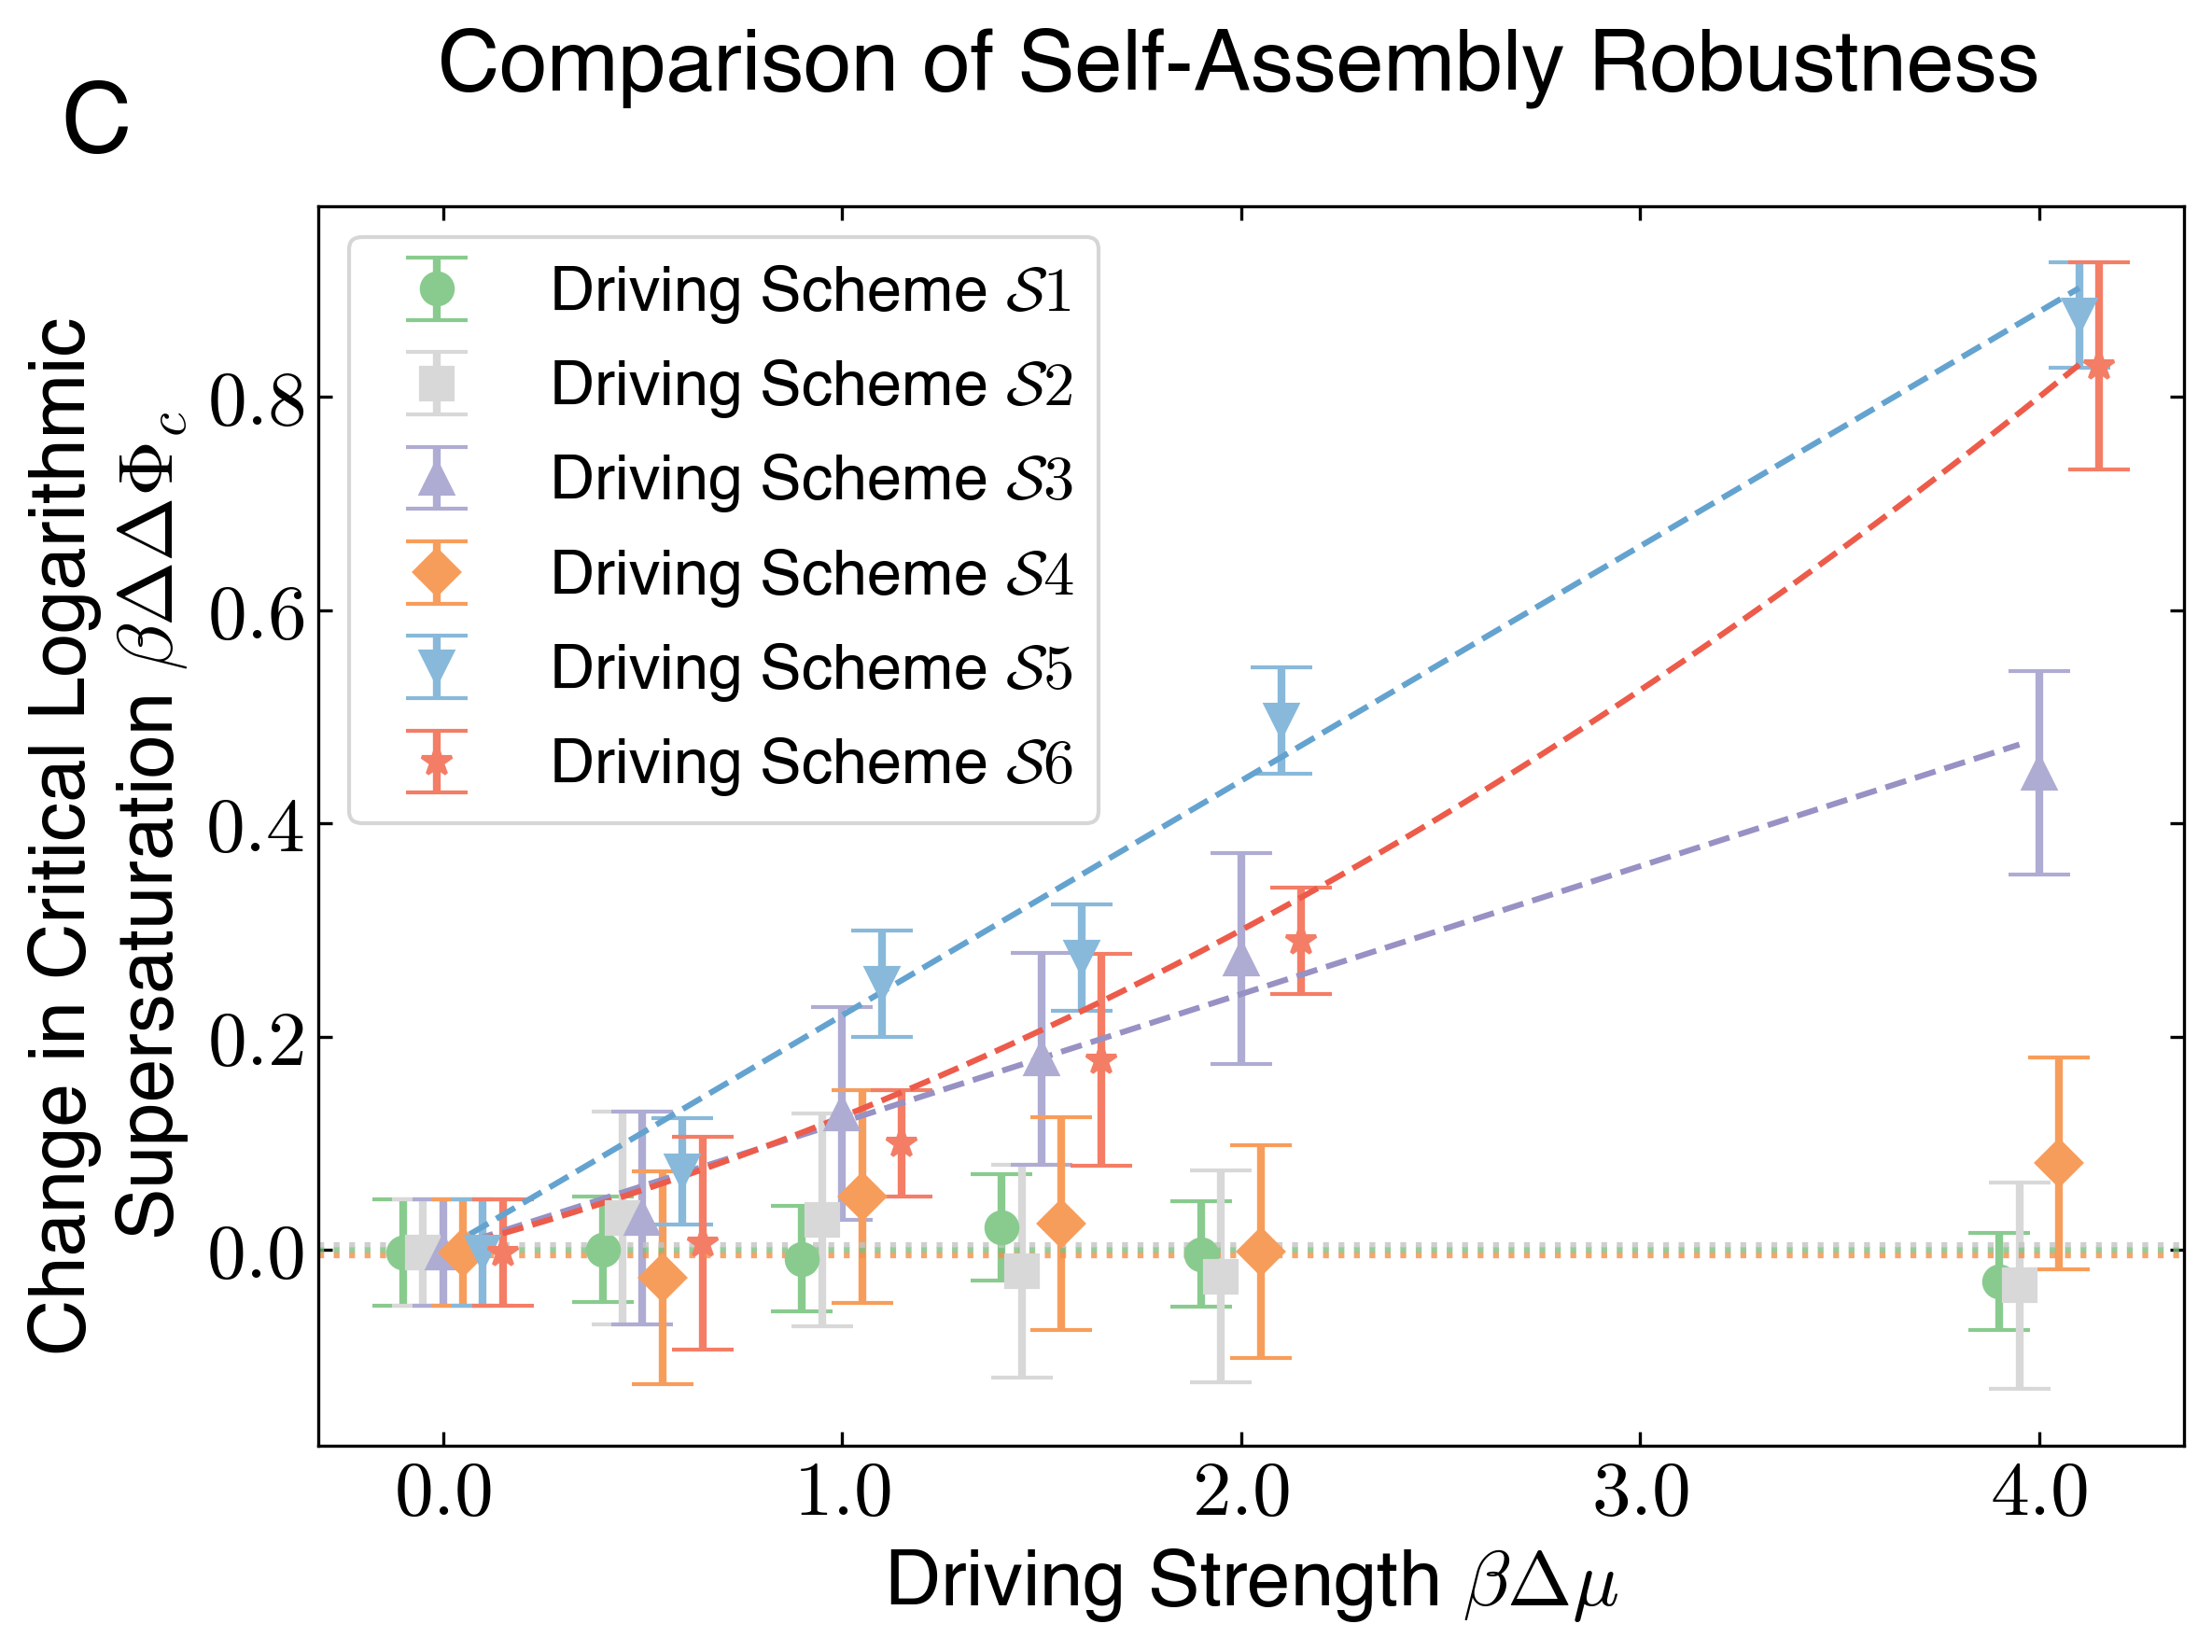

In [48]:
from scipy.interpolate import make_interp_spline

fig, ax = plt.subplots(1,1, figsize=(8,6), sharex=True, sharey=True)

files = ["/Volumes/2025/2026_paper/COMPARING_SCHEMES/HOMO_data_df0.0_k1.0.csv",
         "/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME91_data_df0.0_k1.0.csv",
    "/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME93_data_df0.0_k1.0.csv",
    "/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME3_data_df0.0_k1.0.csv",
    "/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME6_data_df0.0_k1.0.csv",
         "/Volumes/2025/2026_paper/COMPARING_SCHEMES/SCHEME7_data_df0.0_k1.0.csv",
         ]
colors = [ sns.color_palette(palette='Greens_d', n_colors=12),
          sns.color_palette(palette='grey_r', n_colors=12),
            sns.color_palette(palette='Purples_d', n_colors=12),
            sns.color_palette(palette='Oranges_d', n_colors=12),
            sns.color_palette(palette='Blues_d', n_colors=12),
          sns.color_palette(palette='Reds_d', n_colors=12)]
scheme_labels = [1, 2, 3, 4, 5,6]
markers = ['o', 's', '^', 'D', 'v', '*']

offsets = [-0.1, -0.05, 0.0, 0.05, 0.1, 0.15]

for filex, colorx, label, marker, offset in zip(files, colors, scheme_labels, markers, offsets):

    s6 = pd.read_csv(filex)

    critical_dphis = []
    errors_dphis = []
    
    print(filex)
    for dmu in s6['dmu'].unique():
        print(dmu)
        data = s6[s6['dmu'] == dmu]
        idx = (data["m"] - 0.5).abs().idxmin()
        dphi_closest_05 = data.loc[idx, "dphi"]
        m_closest_05 = data.loc[idx, "m"]
        # print(dphi_closest_05, m_closest_05)
        critical_dphis.append(dphi_closest_05 - 0.3)
        try:
            dphi_second_closest_05 = data.loc[idx+1, "dphi"]
            dphi_second_closest_05_2 = data.loc[idx-1, "dphi"]
            average_error = 0.5*(np.abs(dphi_second_closest_05 - dphi_closest_05) + np.abs(dphi_second_closest_05_2 - dphi_closest_05))
            errors_dphis.append(average_error)
        except KeyError:
            dphi_second_closest_05 = data.loc[idx+1, "dphi"]
            errors_dphis.append(np.abs(dphi_second_closest_05 - dphi_closest_05))
    x_vals = s6['dmu'].unique() + offset
    ax.errorbar(x_vals, critical_dphis, yerr=errors_dphis, fmt=marker, capsize=8, ms=8, color=colorx[1], label=r'Driving Scheme $\mathcal{S}' + str(label) + '$',
                lw=2, ls='none')
    # ax.errorbar(s6['dmu'].unique(), critical_dphis, yerr=errors_dphis, color=colorx[0],
    #                  ms=0, ls='dotted', capsize=0, alpha=ALPHA, lw=2.0)



FS_LABELS = 20

ax.legend(fontsize=16, loc='upper left')


ax.set_xlabel(r'Driving Strength $\beta \Delta \mu$', fontsize=FS_LABELS)
ax.set_ylabel('Change in Critical Logarithmic \n' + r'Supersaturation ' + r'$\beta \Delta \Delta \Phi_c$', fontsize=FS_LABELS)
ax.set_xticks([0,1,2,3,4], [r"$0.0$", r"$1.0$", r"$2.0$", r"$3.0$", r"$4.0$"], fontsize=FS_LABELS)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], [r"$0.0$", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$", r"$1.0$"], fontsize=FS_LABELS)

ax.axhline(0.00, ls='dotted', alpha=ALPHA, color=colors[0][2])
ax.axhline(0.005, ls='dotted', alpha=ALPHA, color=colors[1][2])
ax.axhline(-0.005, ls='dotted', alpha=ALPHA, color=colors[3][2])

ax.text(
    -0.1,
    1.1,
    "C",
    transform=ax.transAxes,
    fontsize=25,
    fontweight="bold",
    va="top",
    ha="right",
)

ax.set_title('Comparison of Self-Assembly Robustness \n', fontsize=22)

x_cont = np.linspace(0,3.95,1000)
y_1 = 0.12*x_cont
plt.plot(x_cont, y_1, ls='dashed', color=colors[2][3])

x_cont = np.linspace(0,4.1,1000)
y_1 = 0.22*x_cont
plt.plot(x_cont, y_1, ls='dashed', color=colors[4][3])

x_cont = np.linspace(0,4.1,1000)
y_1 = 0.1*x_cont + 0.025*x_cont**2
plt.plot(x_cont, y_1, ls='dashed', color=colors[5][3])

plt.tight_layout()
plt.savefig('additonal.pdf', dpi=300, bbox_inches='tight')

INFO:root:Initialized DynamicalOrderDisorder analysis for test with 14 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for test with 14 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for test with 14 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for test with 14 CSV files


Whiteout mode set.


INFO:root:Initialized DynamicalOrderDisorder analysis for test with 14 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for test with 14 CSV files


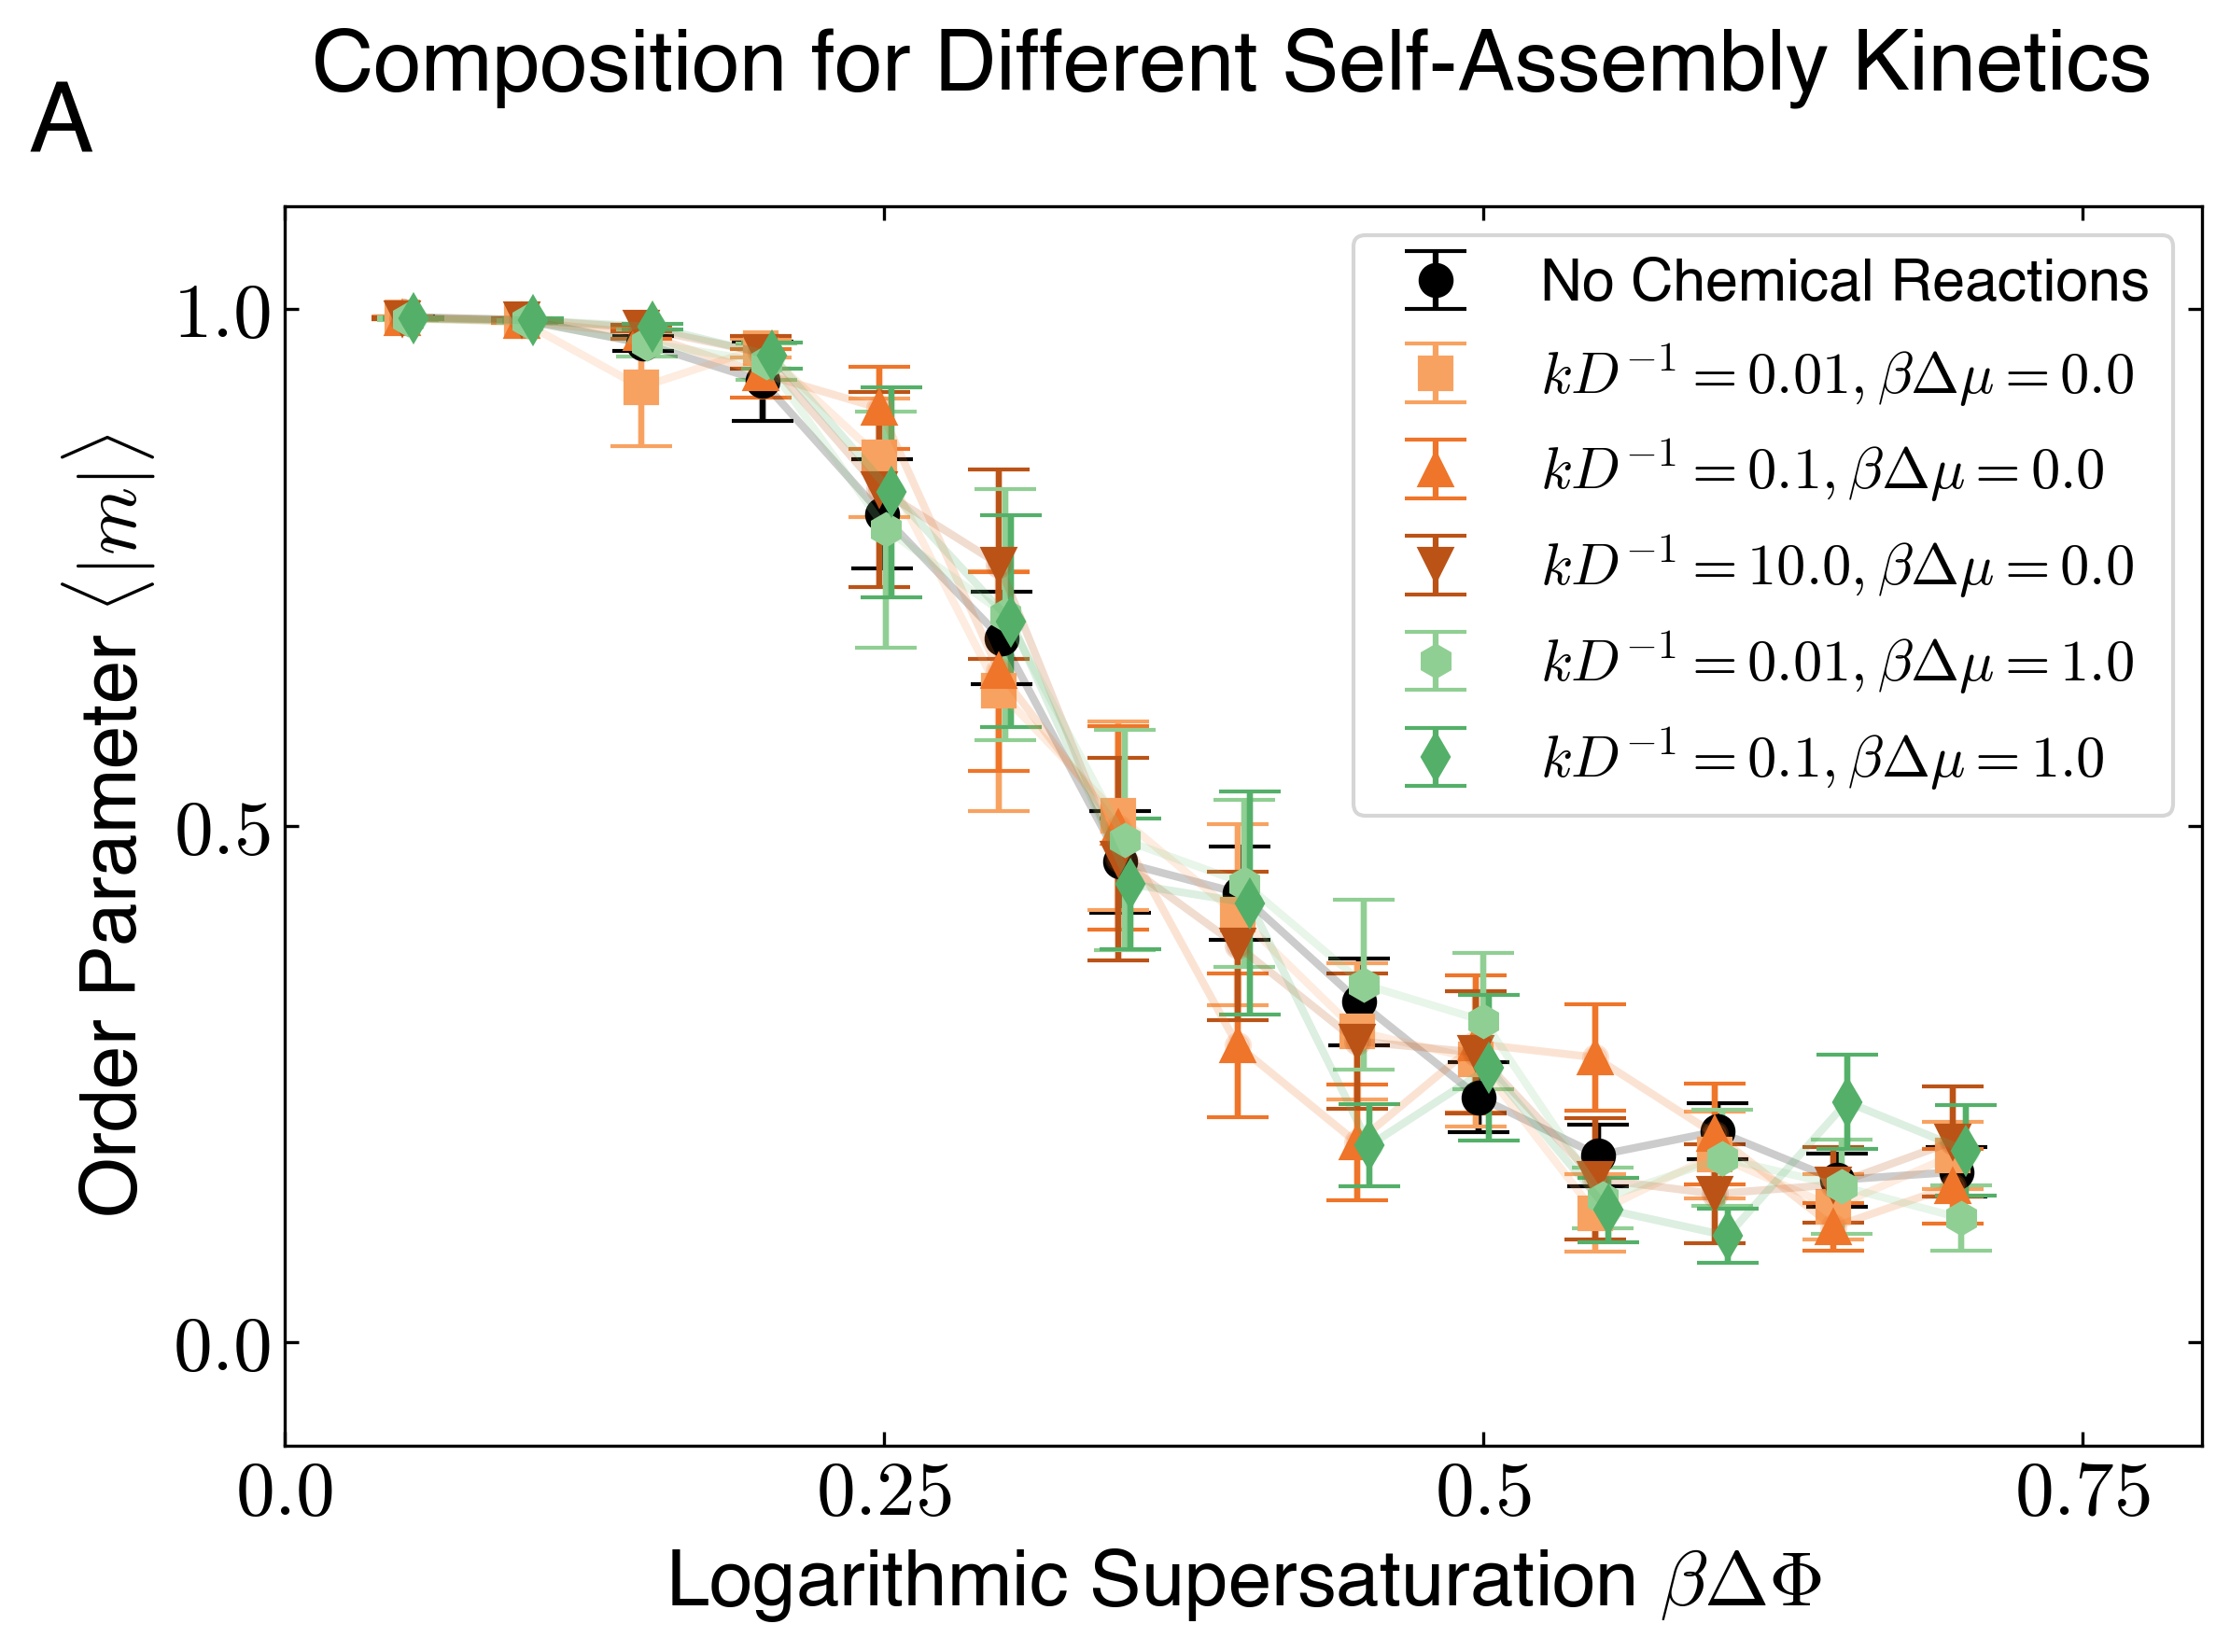

In [46]:
colors = sns.color_palette(palette='Oranges_d', n_colors=7)


whiteout()
fig, ax = plt.subplots(1,1, figsize=(8,6), sharey=True)


base_path = Path(f"/Volumes/2025/2026_paper/NO_CHANGE_IN_SUPERSAT/-3.5_K_0.0_FRES_-20.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.50, fres=-20.0, k=0.0, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)


ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"No Chemical Reactions", linestyle="none", ms=8, marker="o", color='k',
               capsize=8)
ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], linestyle="solid", lw=2, marker="o", color='k',alpha=0.2)

base_path = Path(f"/Volumes/2025/2026_paper/NO_CHANGE_IN_SUPERSAT/-3.5_K_0.01_FRES_-1.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.50, fres=-1.0, k=0.01, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)

ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"$kD^{-1} = 0.01, \beta \Delta \mu = 0.0$", linestyle="none", ms=8, marker="s", color=colors[0],
               capsize=8)
ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], linestyle="solid", lw=2, marker="o", color=colors[0],alpha=0.2)

base_path = Path(f"/Volumes/2025/2026_paper/NO_CHANGE_IN_SUPERSAT/-3.5_K_0.1_FRES_-1.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.50, fres=-1.0, k=0.1, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)

ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"$kD^{-1} = 0.1, \beta \Delta \mu = 0.0$", linestyle="none", ms=8, marker="^", color=colors[2],
               capsize=8)
ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], linestyle="solid", lw=2, marker="o", color=colors[2],alpha=0.2)

base_path = Path(f"/Volumes/2025/2026_paper/NO_CHANGE_IN_SUPERSAT/-3.5_K_10.0_FRES_-1.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.50, fres=-1.0, k=10.0, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)

ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"$kD^{-1} = 10.0, \beta \Delta \mu = 0.0$", linestyle="none", ms=8, marker="v", color=colors[4],
               capsize=8)
ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], linestyle="solid", lw=2, marker="o", color=colors[4],alpha=0.2)


colors = sns.color_palette(palette='Greens_d', n_colors=7)

base_path = Path(f"/Volumes/2025/2026_paper/NO_CHANGE_IN_SUPERSAT/-3.5_K_0.01_FRES_0.0_DRIVE_1.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.50, fres=0.0, k=0.01, dmu=1.0, method='HOMO')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)

ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"$kD^{-1} = 0.01, \beta \Delta \mu = 1.0$", linestyle="none", ms=8, marker="h", color=colors[0],capsize=8)
ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], linestyle="solid", lw=2, marker="o", color=colors[0],alpha=0.2)

base_path = Path(f"/Volumes/2025/2026_paper/NO_CHANGE_IN_SUPERSAT/-3.5_K_0.1_FRES_0.0_DRIVE_1.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.50, fres=0.0, k=0.1, dmu=1.0, method='HOMO')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)

ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"$kD^{-1} = 0.1, \beta \Delta \mu = 1.0$", linestyle="none", ms=8, marker="d", color=colors[2],capsize=8)
ax.errorbar(data['dphi'], data["m"],yerr=data['dm'], linestyle="solid", lw=2, marker="o", color=colors[2],alpha=0.2)

ax.legend(fontsize=15, loc='upper right')

ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0.0, 0.5, 1.0], [r"$0.0$", r"$0.5$", r"$1.0$"], fontsize=FS_LABELS)

ax.set_xlim(0,0.8)
ax.set_xticks([0.0, 0.25, 0.5, 0.75], [r"$0.0$", r"$0.25$", r"$0.5$", r"$0.75$"], fontsize=FS_LABELS)


ax.set_xlabel(r"Logarithmic Supersaturation $\beta \Delta \Phi$", fontsize=FS_LABELS)
ax.set_ylabel(r"Order Parameter $\langle \vert m \vert \rangle$", fontsize=FS_LABELS)


ax.text(
    -0.1,
    1.1,
    "A",
    transform=ax.transAxes,
    fontsize=25,
    fontweight="bold",
    va="top",
    ha="right",
)

ax.set_title('Composition for Different Self-Assembly Kinetics \n', fontsize=22)


plt.tight_layout()
plt.savefig("order_parameter_vs_dphi_and_growth_speed_bright.pdf", bbox_inches='tight')

INFO:root:Initialized DynamicalOrderDisorder analysis for test with 18 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for test with 22 CSV files


Critical dphi: 0.2680209995414965, Error: 0.04977210501682139


INFO:root:Initialized DynamicalOrderDisorder analysis for test with 16 CSV files


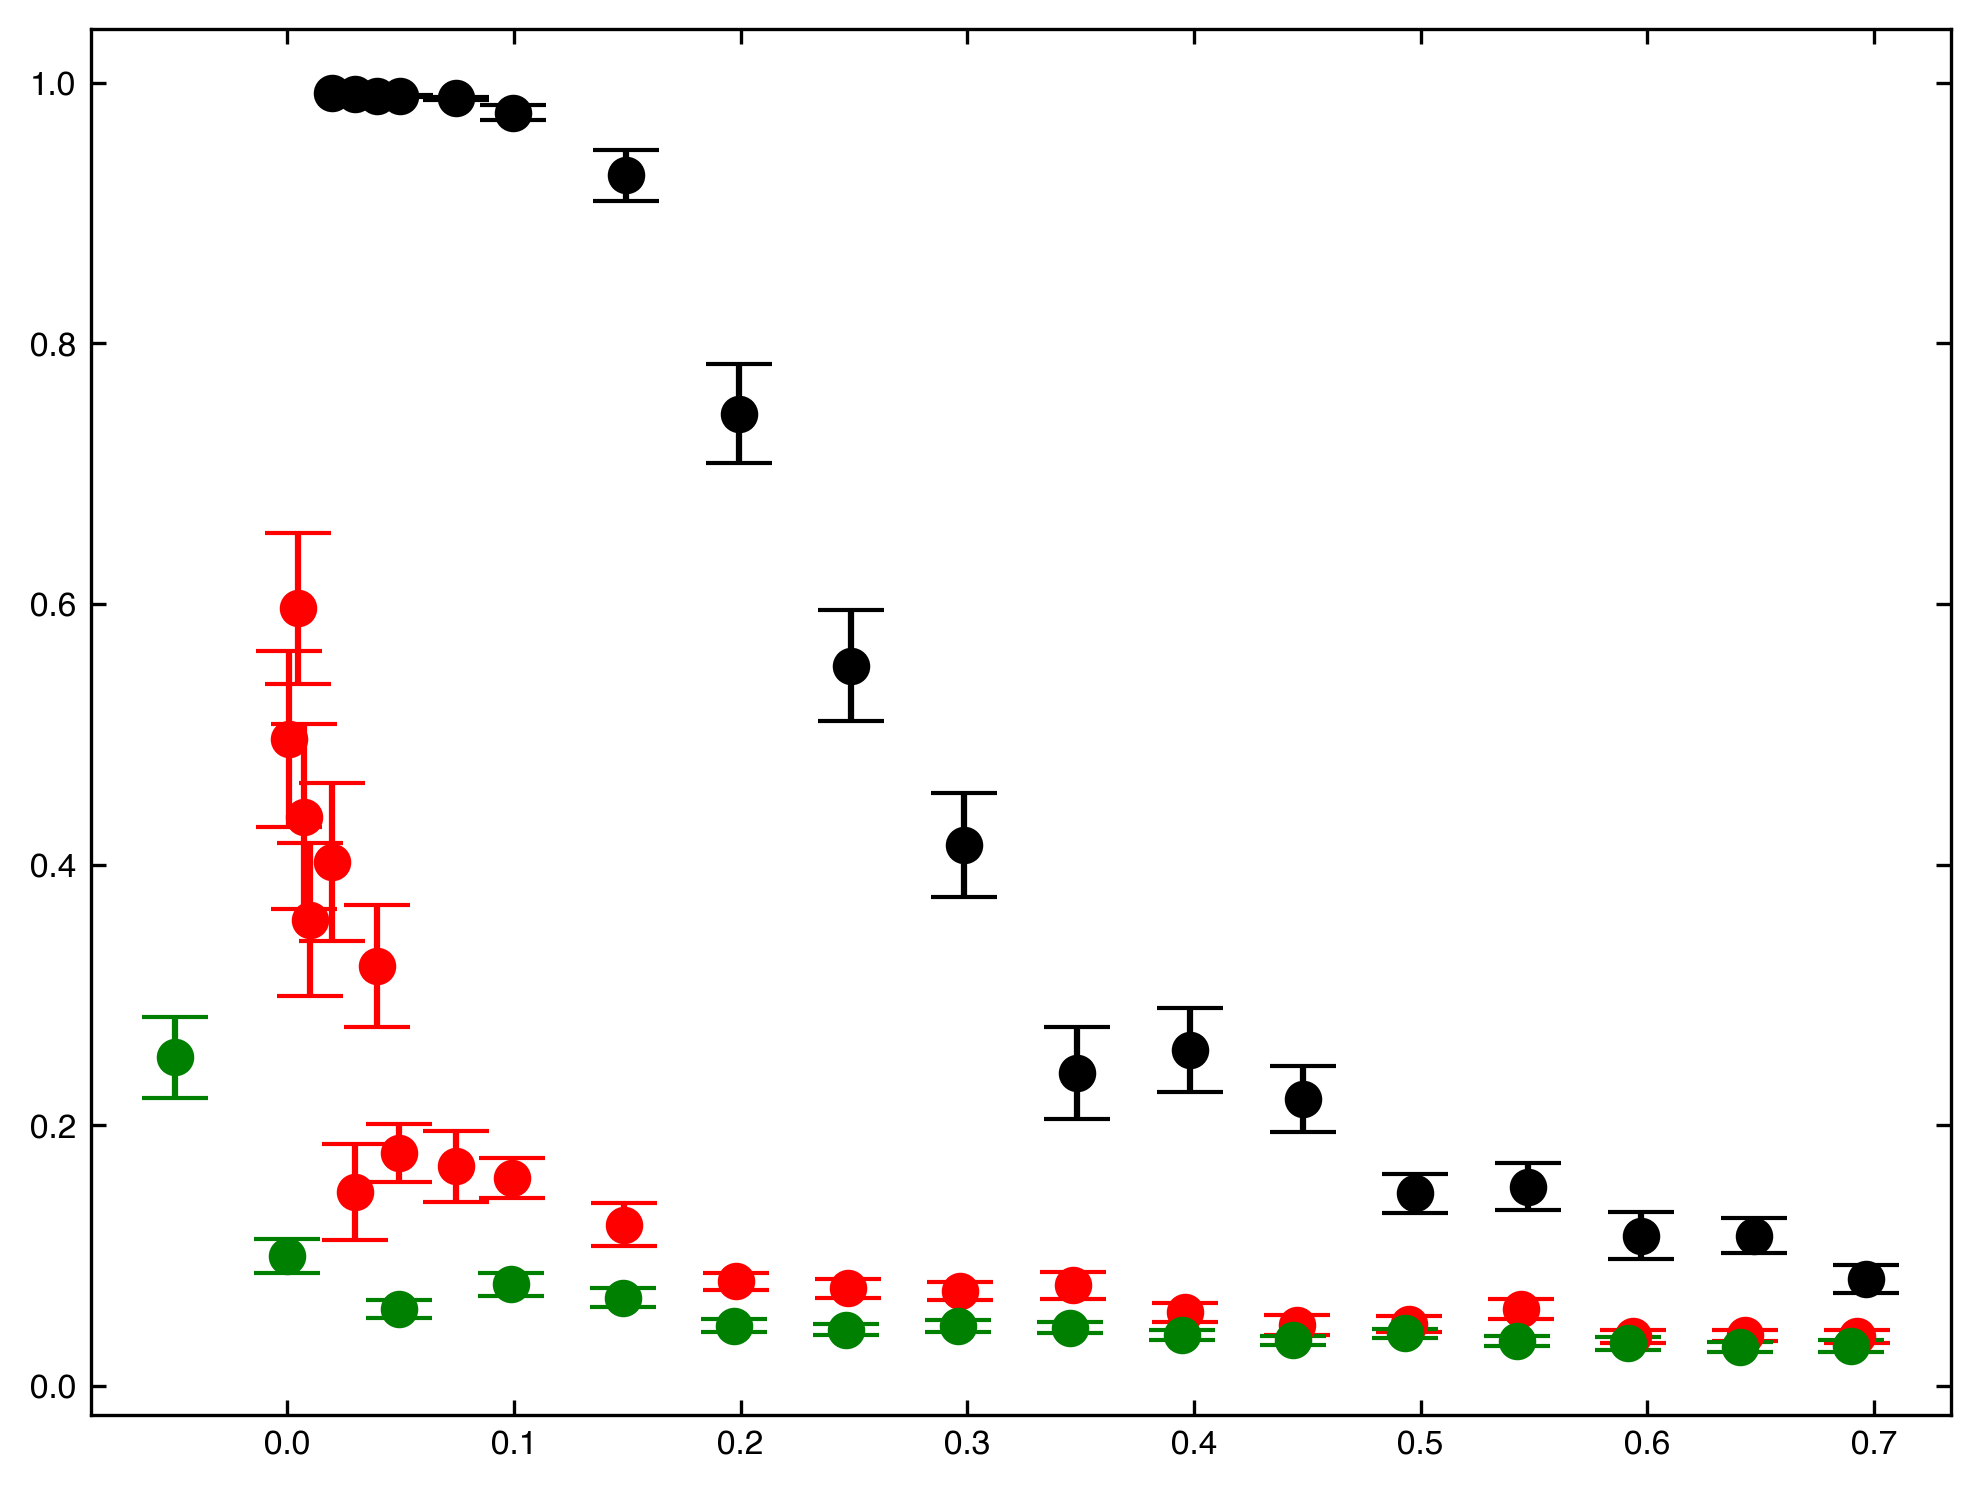

In [13]:
def estimate_critical_point(data_frame):
    data = data_frame.sort_values(by=["dphi"], ignore_index=True)
    idx = (data["m"] - 0.5).abs().idxmin()
    critical_dphi = data.loc[idx, "dphi"]
    upper_limit = data.loc[idx-1, "dphi"]
    lower_limit = data.loc[idx+1, "dphi"]
    error = max(abs(critical_dphi - upper_limit), abs(critical_dphi - lower_limit))

    dphi_grid = np.linspace(data["dphi"].min(), data["dphi"].max(), 10000)
    m_grid = np.interp(dphi_grid, data["dphi"].to_numpy(), data["m"].to_numpy())
    grid_idx = np.abs(m_grid - 0.5).argmin()
    critical_dphi = dphi_grid[grid_idx]

    return (critical_dphi, error)

base_path = Path(f"/Volumes/2025/2026_paper/PHASE_DIAGRAM/-3.4_K_0.0_FRES_-20.0_DRIVE_0.0/-3.4_K_0.0_FRES_-20.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.40, fres=-20.0, k=0.0, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)


plt.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"No Chemical Reactions", linestyle="none", ms=8, marker="o", color='k',
               capsize=8)

critical_dphi, error = estimate_critical_point(data)
print(f"Critical dphi: {critical_dphi}, Error: {error}"
      )
base_path = Path(f"/Volumes/2025/2026_paper/PHASE_DIAGRAM/-3.0_K_0.0_FRES_-20.0_DRIVE_0.0/-3.0_K_0.0_FRES_-20.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-3.00, fres=-20.0, k=0.0, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)


plt.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"No Chemical Reactions", linestyle="none", ms=8, marker="o", color='r',
               capsize=8)


base_path = Path(f"/Volumes/2025/2026_paper/PHASE_DIAGRAM/-2.85_K_0.0_FRES_-20.0_DRIVE_0.0/-2.85_K_0.0_FRES_-20.0_DRIVE_0.0")
analysis = npa.DynamicalOrderDisorder("test", base_path)
thermos_for_inert = npa.Thermos(jhom=-2.85, fres=-20.0, k=0.0, dmu=0.0, method='NODRIVE')
data = analysis.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)


plt.errorbar(data['dphi'], data["m"],yerr=data['dm'], label=r"No Chemical Reactions", linestyle="none", ms=8, marker="o", color='g',
               capsize=8)

plt.grid(True)

     L  epsilon     chi_mean  chi_stderr  log_chi_mean     log_L
0   16   -1.655    14.965068    0.215645      1.175079  1.204120
1   32   -1.715    49.164219    1.783760      1.691649  1.505150
2   48   -1.735    95.934413    6.189222      1.981974  1.681241
3   64   -1.740   163.260814   12.051978      2.212882  1.806180
4   96   -1.755   330.152281   42.279185      2.518714  1.982271
5  128   -1.755   502.520419   53.403258      2.701154  2.107210
6  256   -1.755  1087.903512  187.384582      3.036590  2.408240
Leave-one-out slopes: [1.51819175 1.58040562 1.58445669 1.58425864 1.57042165 1.5647753
 1.70445667]
Average slope: 1.586709
Slope std (sample): 0.056798
Slope stderr of mean: 0.021468
     L  epsilon     chi_mean  chi_stderr  log_chi_mean     log_L
0   16   -1.645    14.711963    0.232389      1.167671  1.204120
1   32   -1.710    50.471184    1.641822      1.703043  1.505150
2   48   -1.745   106.595522   12.039059      2.027739  1.681241
3   64   -1.735   161.692299   10.0

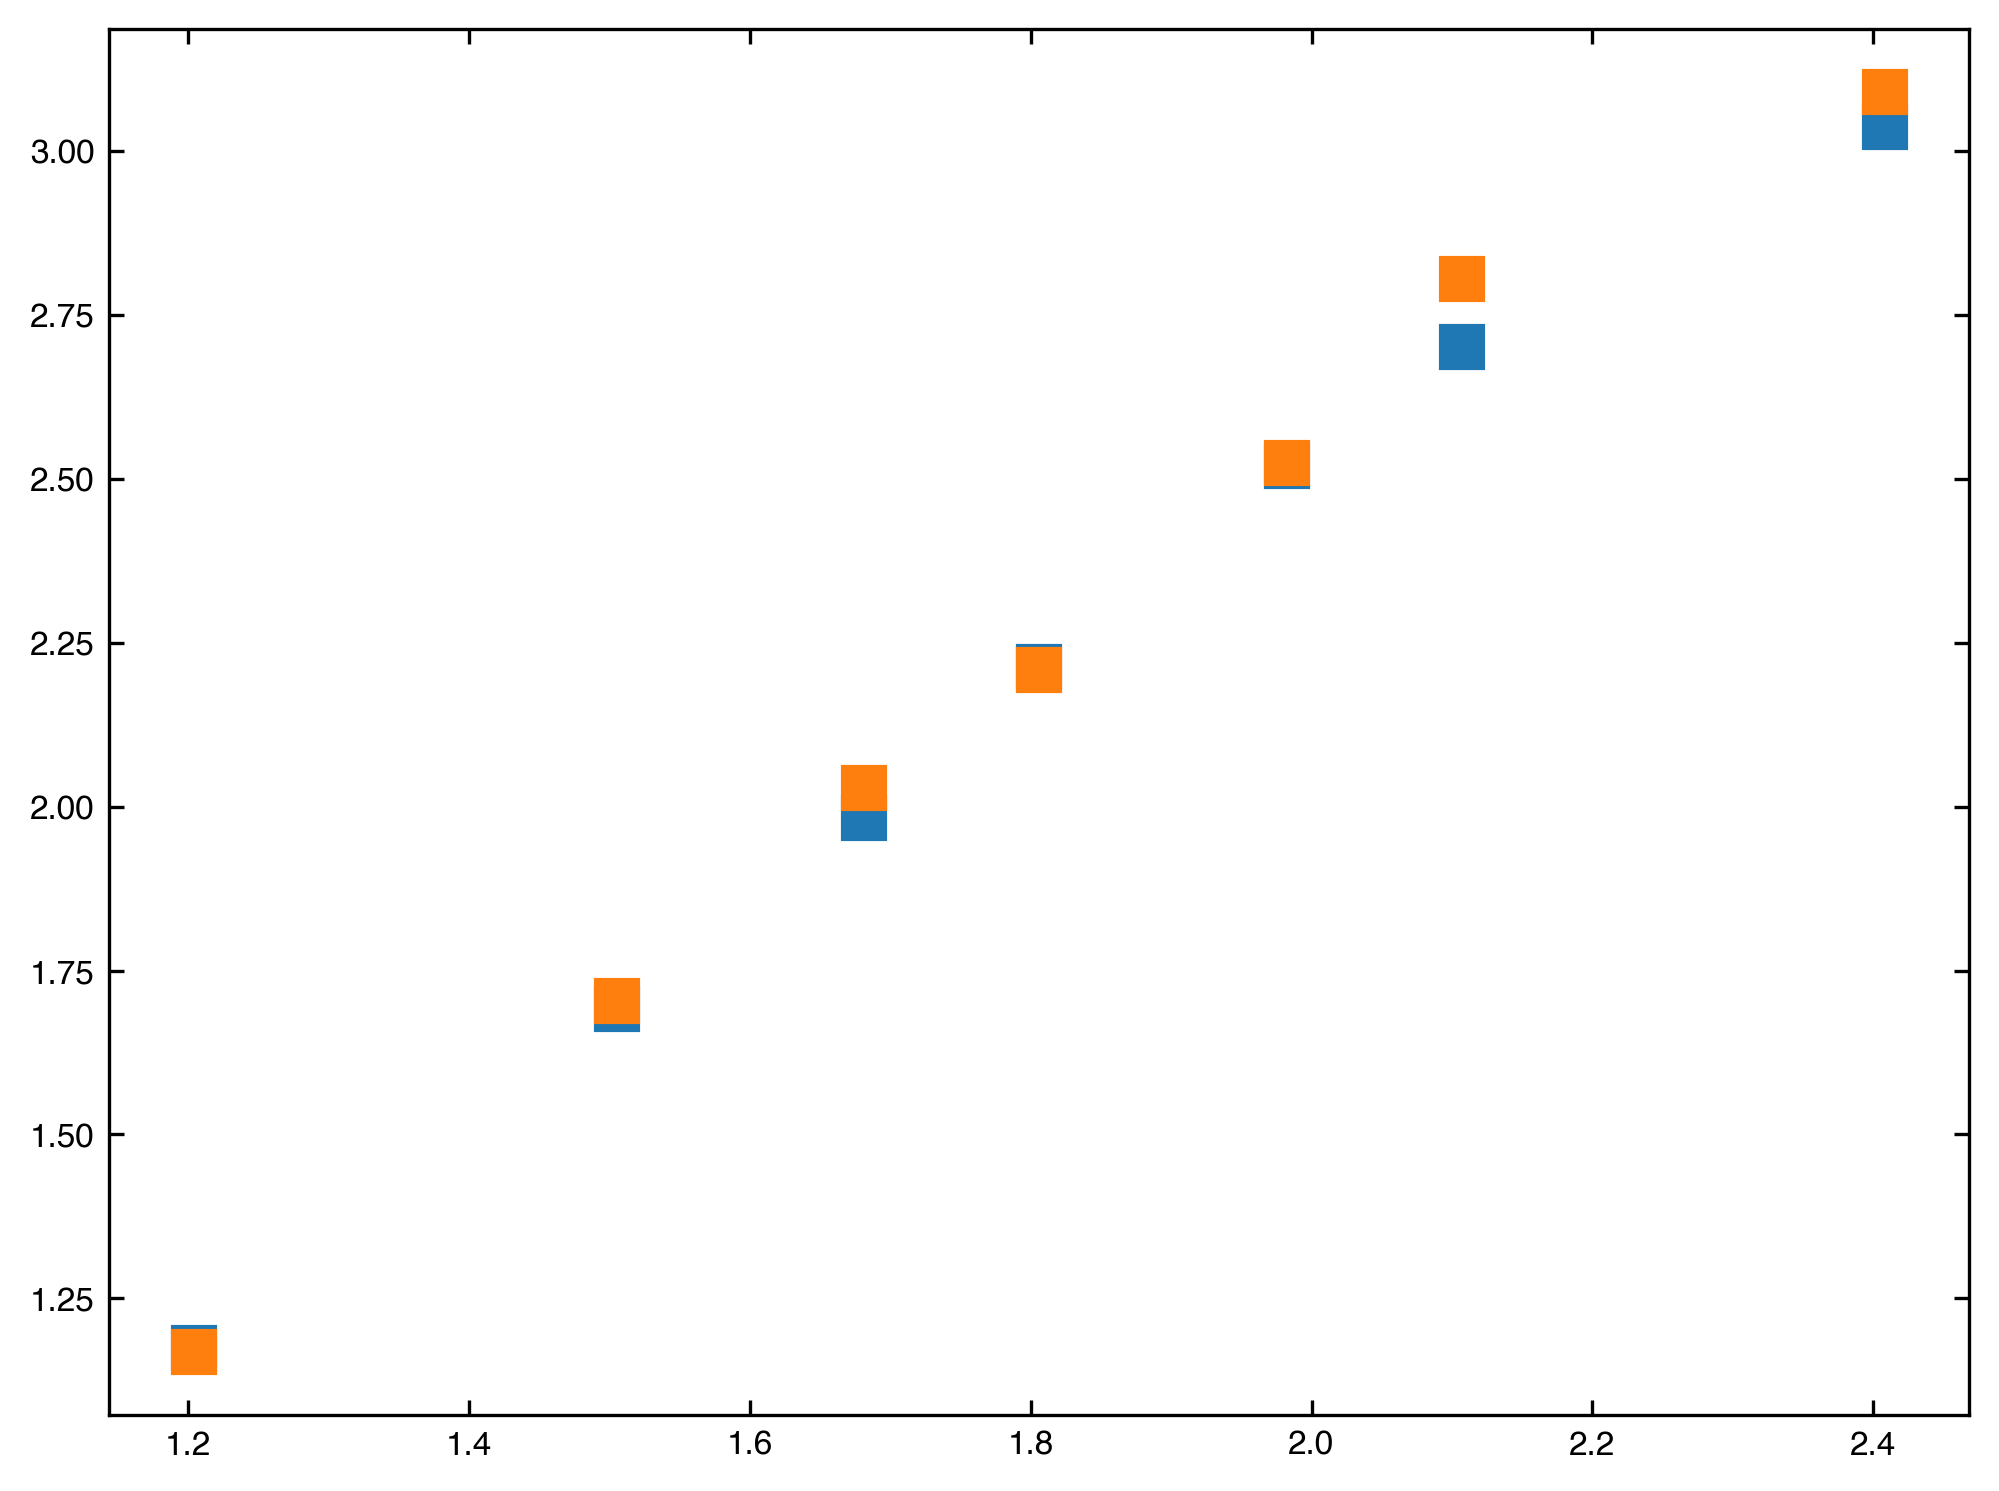

In [25]:
vincent_data = pd.read_csv("/Users/moritzobenauer/Projects/nesspy_analysis/2025/data.csv")
vincent_data['log_chi_mean'] = np.log10(vincent_data['chi_mean'])
vincent_data['log_L'] = np.log10(vincent_data['L'])
print(vincent_data)
plt.plot(vincent_data['log_L'], vincent_data['log_chi_mean'], lw=0, ms=10, marker='s')

# fit the data to a linear model
from scipy.stats import linregress
slopes = []
for i in range(len(vincent_data)):
    mask = vincent_data.index != i
    x = vincent_data.loc[mask, 'log_L']
    y = vincent_data.loc[mask, 'log_chi_mean']
    s, intercept_i, r, p, se = linregress(x, y)
    slopes.append(s)

slopes = np.array(slopes)
mean_slope = slopes.mean()
std_slope = slopes.std(ddof=1)
stderr_mean = std_slope / np.sqrt(len(slopes))

print(f"Leave-one-out slopes: {slopes}")
print(f"Average slope: {mean_slope:.6f}")
print(f"Slope std (sample): {std_slope:.6f}")
print(f"Slope stderr of mean: {stderr_mean:.6f}")

vincent_data = pd.read_csv("/Users/moritzobenauer/Projects/nesspy_analysis/2025/data_50.csv")
vincent_data['log_chi_mean'] = np.log10(vincent_data['chi_mean'])
vincent_data['log_L'] = np.log10(vincent_data['L'])
print(vincent_data)
plt.plot(vincent_data['log_L'], vincent_data['log_chi_mean'], lw=0, ms=10, marker='s')

# fit the data to a linear model
from scipy.stats import linregress
slopes = []
for i in range(len(vincent_data)):
    mask = vincent_data.index != i
    x = vincent_data.loc[mask, 'log_L']
    y = vincent_data.loc[mask, 'log_chi_mean']
    s, intercept_i, r, p, se = linregress(x, y)
    slopes.append(s)

slopes = np.array(slopes)
mean_slope = slopes.mean()
std_slope = slopes.std(ddof=1)
stderr_mean = std_slope / np.sqrt(len(slopes))

print(f"Leave-one-out slopes: {slopes}")
print(f"Average slope: {mean_slope:.6f}")
print(f"Slope std (sample): {std_slope:.6f}")
print(f"Slope stderr of mean: {stderr_mean:.6f}")


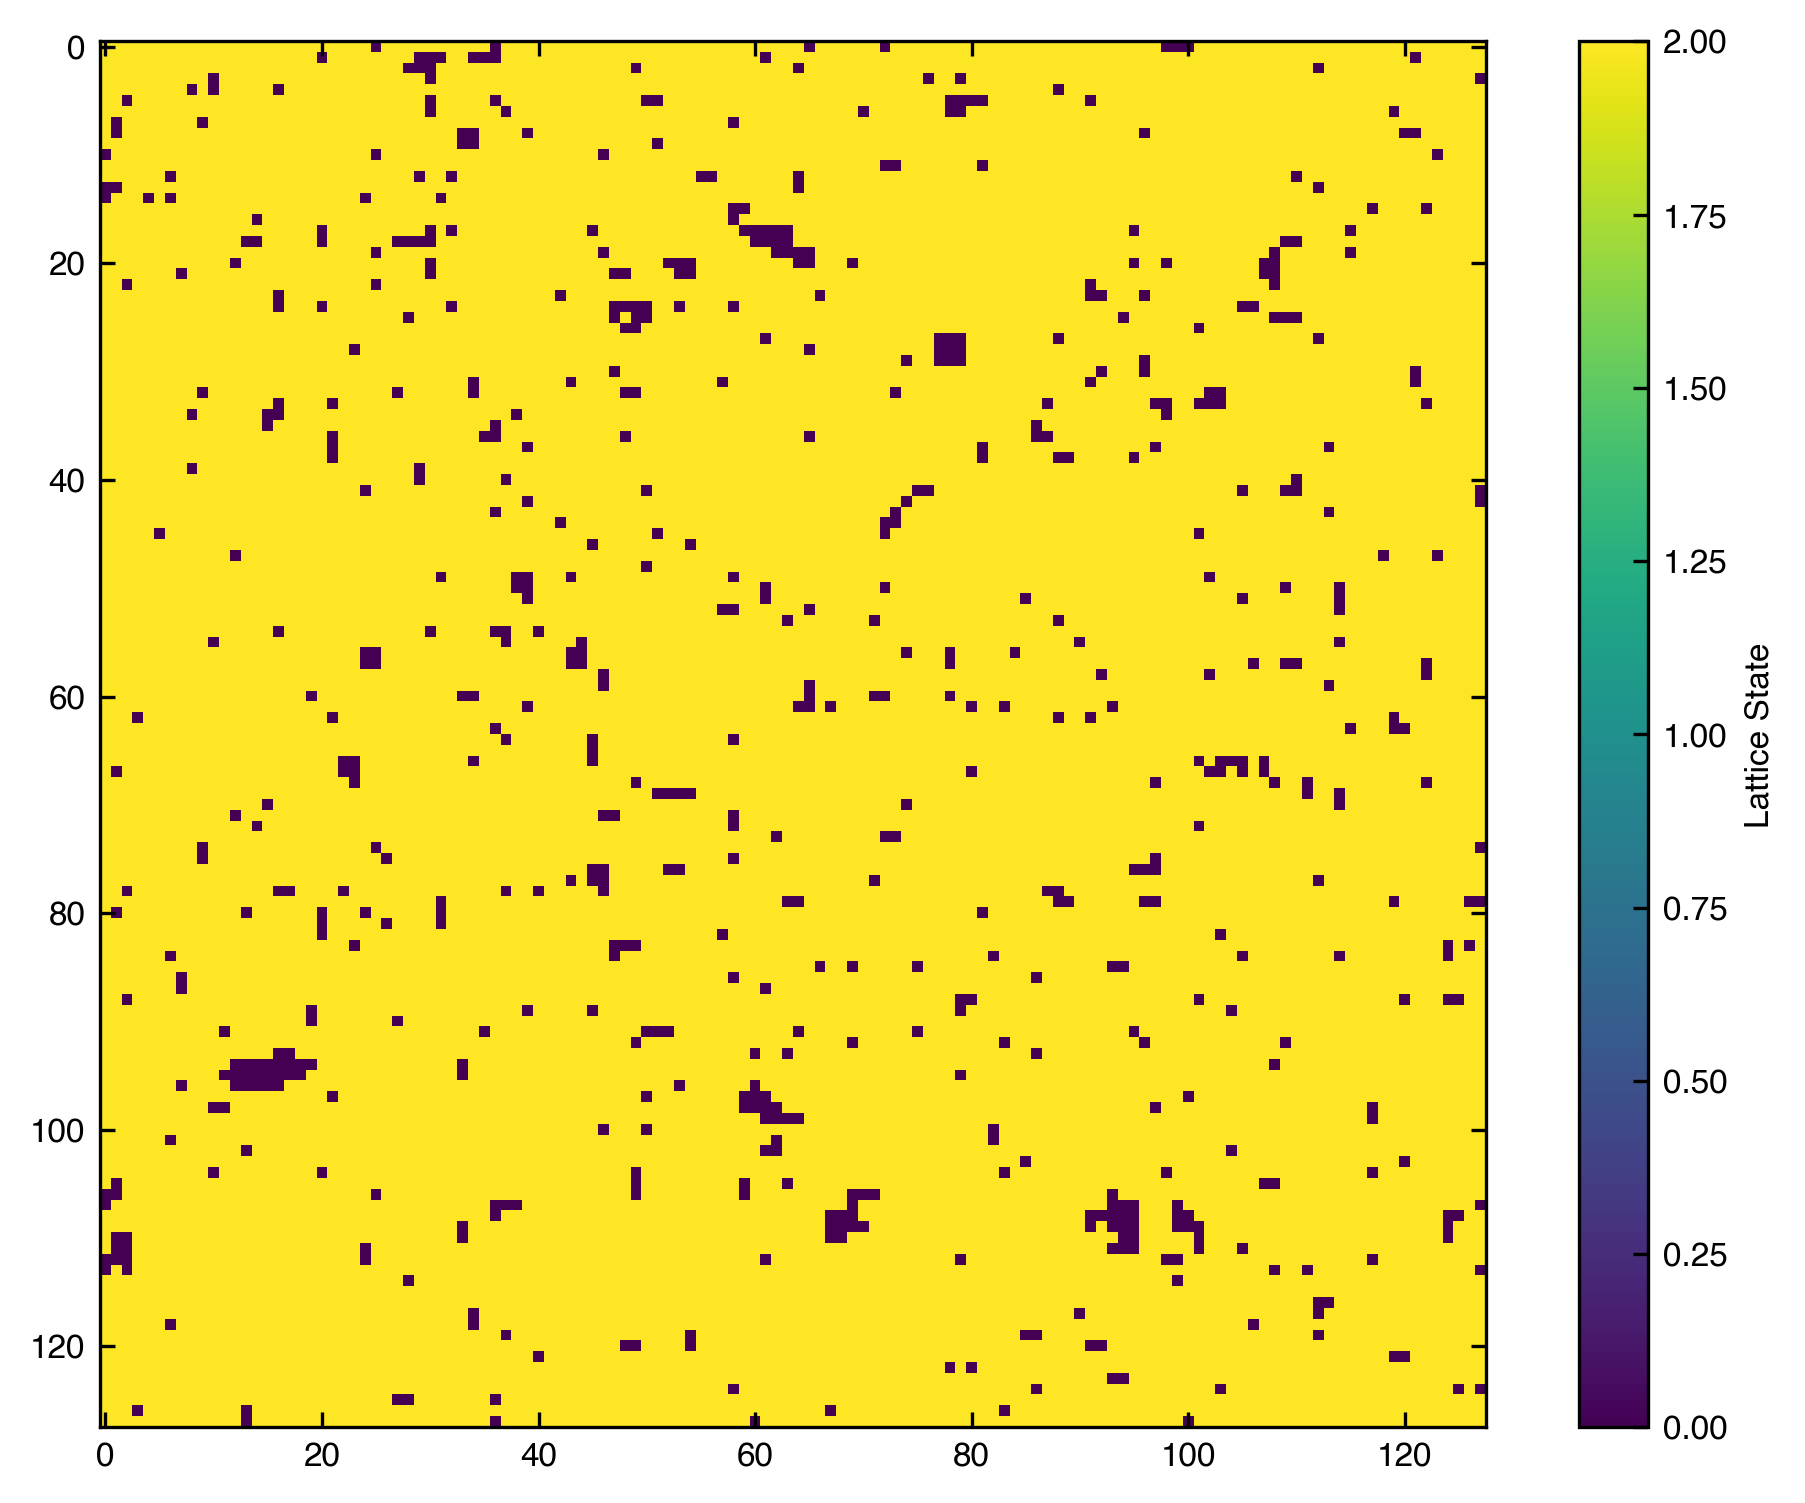

In [29]:
lattice = np.load("/Users/moritzobenauer/Downloads/final_lattice_0.npy")
plt.imshow(lattice, cmap='viridis', interpolation='nearest' )
plt.colorbar(label='Lattice State')